<!-- config-banner -->
# Kappa_v ensemble — accumulated sensitivity maps across members

**Notebook 03 of the kappa_v ensemble suite** (analysis date **2026-08-30**; runs submitted 2026-08-28).

**Question**: what does each member's fully accumulated (lead 5 yr) adjoint sensitivity look
like, side by side across the &kappa;<sub>v</sub> factors 0.25&times;&ndash;32&times; — and **which members are
physically usable**? Four of the seven member adjoints blow up during the reverse sweep,
so this notebook both maps the sensitivities and classifies the runs, handing the usable
subset (and each blown member's usable lead-time window) to notebooks 04/05.

**Reads** (produced by `build_cache.py`; all under
`/scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/cache/`):
`run_table.csv`, `stable_runs.npy`, `final_fields_3d.nc` (lead-5-yr ADJ* snapshots),
`adxx_fields_3d.nc` (control gradients), `member_metrics_time.nc` (member-vs-REF metrics
per dump). The grid is read from the reference run directory via `ensemble_common`.

**Writes**: figures to `.../kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/`
and one reusable CSV (per-member usable lead windows) to `.../stats/`. Nothing is written
into the repository.

Run registry, job IDs and the suite reading order: see `README.md` in this directory.
Shared conventions (masking, colour rules, metric definitions): `ensemble_common.py`.

## Setup

Everything heavy was precomputed by `build_cache.py`; this notebook only reads cache
files, so it is light on memory (the largest input, `final_fields_3d.nc`, is ~70 MB).

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import ensemble_common as ec

ec.setup_style()
NB_STEM = "03_ensemble_sensitivity_maps"

# Blown-up adjoints hold values up to the float32 range (~1e38) and, in M4, inf/NaN.
# Squaring those for an RMS overflows, and numpy would emit a RuntimeWarning for nearly
# every panel involving M1/M4/M5/M7, drowning the real output — so overflow/invalid
# warnings are silenced. Nothing is hidden by this: the affected values are mapped,
# counted and printed explicitly below.
np.seterr(over="ignore", invalid="ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)

G = ec.read_grid()
WET = G["wetC"]                       # (k, j, i) boolean wet mask, tracer points
FINAL3 = ec.open_cache("final_fields_3d.nc")     # lead-5-yr ADJ* snapshots, all runs
ADXX3 = ec.open_cache("adxx_fields_3d.nc")       # control gradients (float64)
MMT = ec.open_cache("member_metrics_time.nc")    # member-vs-REF metrics per dump
RUN_TABLE = pd.read_csv(ec.CACHE_DIR / "run_table.csv")
STABLE = [str(r) for r in np.load(ec.CACHE_DIR / "stable_runs.npy")]
BLOWN = [r for r in ec.RUN_ORDER if r not in STABLE]

KSHOW = [14, 24]   # display levels: mid-thermocline and near the cost-integral base
for k in KSHOW:
    print(f"k={k}: Z = {G['Z'][k]:7.1f} m   ({int(WET[k].sum())} wet cells)")
print(f"wet C cells total: {int(WET.sum())}  ({WET.sum()/WET.size:.1%} of the box)")
print(f"cost section row: j={ec.JSEC} (python) = {ec.JSEC+1} (fortran), "
      f"lat {G['YC'][ec.JSEC, 25]:.2f} N; cost integral over k<{ec.KMAX}")
print("runs by kappa factor:", {r: ec.RUNS[r]["factor"] for r in ec.RUN_ORDER})
print("stable subset (build_cache criterion):", STABLE, "   blown:", BLOWN)


def wet_rms(a):
    """RMS over the finite values of an already wet-selected 1-D array."""
    a = np.asarray(a, np.float64)
    a = a[np.isfinite(a)]
    return float(np.sqrt(np.mean(a * a))) if a.size else np.nan


def field_at(run, var, k=None):
    """Final-snapshot (lead 5 yr) field of one run, land as NaN, float64."""
    f = FINAL3.field.sel(run=run, var=var).values.astype(np.float64)
    f = np.where(WET, f, np.nan)
    return f if k is None else f[k]


def panel(ax, fld, vmax, cmap="RdBu_r", vmin=None, title=""):
    """One small-multiple map panel (no own colorbar; caller decides)."""
    cmo = plt.get_cmap(cmap).copy()
    cmo.set_bad("0.82")
    if vmin is None:
        vmin = -vmax
    pm = ax.pcolormesh(G["XC"], G["YC"], fld, cmap=cmo, vmin=vmin, vmax=vmax,
                       shading="auto", rasterized=True)
    ax.set_title(title, fontsize=8.5)
    ax.grid(False)
    ax.tick_params(labelsize=7)
    return pm

k=14: Z =  -231.0 m   (9627 wet cells)
k=24: Z =  -915.4 m   (9627 wet cells)
wet C cells total: 332274  (91.4% of the box)
cost section row: j=126 (python) = 127 (fortran), lat 26.05 N; cost integral over k<25
runs by kappa factor: {'M1': 0.25, 'M2': 0.5, 'REF': 1.0, 'M3': 2.0, 'M4': 4.0, 'M5': 8.0, 'M6': 16.0, 'M7': 32.0}
stable subset (build_cache criterion): ['M2', 'REF', 'M3', 'M6']    blown: ['M1', 'M4', 'M5', 'M7']


## 1&nbsp;&nbsp;Run health and classification

The central complication of this ensemble, stated up front: **four of the seven member
adjoints blow up during the reverse sweep** — and the blow-up is **non-monotonic in
&kappa;**. Meanwhile the forward quantity `fc` (the cost `J` written by `pkg/cost`) is
healthy and finite in **all nine** runs: the forward legs and cost evaluations are fine;
only the reverse (adjoint) sweep — the linearised model integrated backwards around each
member's own trajectory — is unstable for some members. All runs use the plain
(non-`adjViscBoost`) build, i.e. `viscFacInAd` is at its default 1; the repo's
`adjViscBoost` variant (`viscFacInAd=10`) exists precisely because long adjoints of this
model can blow up.

**Stability criterion** (from `build_cache.py`, recorded in `stable_runs.npy`): a run is
"stable" iff its final (lead 5 yr) `ADJtheta` is finite at every wet cell **and** its
wet-cell RMS is within a factor 10 of the reference's. The table below adds two
structure checks computed here from the final snapshots (unweighted, over wet cells
finite in both fields): pattern correlation with REF and sign-agreement fraction.
`adxx_vs_ADJdiffkr_corr` is the internal-consistency check between the `pkg/ctrl`
gradient file and the final `ADJdiffkr` dump (expected ~1 by construction).

In [2]:
# health table: run_table columns + final-snapshot structure checks vs REF
ref_th = field_at("REF", "ADJtheta")
ref_wet = ref_th[WET]

rows = []
for run in ec.RUN_ORDER:
    tr = RUN_TABLE.set_index("run").loc[run]
    th = field_at(run, "ADJtheta")[WET]
    both = np.isfinite(th) & np.isfinite(ref_wet)
    corr = ec.pattern_corr(th[both], ref_wet[both]) if run != "REF" else 1.0
    sign = ec.sign_agreement(th[both], ref_wet[both]) if run != "REF" else 1.0
    rows.append(dict(
        run=run,
        factor=ec.RUNS[run]["factor"],
        fc=tr["fc"],
        runtime=tr["runtime"].split()[0],
        dumps=int(tr["n_dumps"]),
        adxx_chk=tr["adxx_vs_ADJdiffkr_corr"],
        rms_final=tr["rms_final_ADJtheta"],
        rms_ratio=tr["rms_final_ADJtheta"] / RUN_TABLE.set_index("run").loc["REF",
                                                       "rms_final_ADJtheta"],
        finite_frac=tr["finite_frac_final_ADJtheta"],
        corr_vs_REF=corr,
        sign_agree=sign,
        stable=run in STABLE,
    ))
health = pd.DataFrame(rows).set_index("run")

with pd.option_context("display.float_format", lambda v: f"{v:.4g}"):
    display(health.style.format({
        "fc": "{:.4f}", "adxx_chk": "{:.6f}", "rms_final": "{:.2e}",
        "rms_ratio": "{:.2e}", "finite_frac": "{:.3f}",
        "corr_vs_REF": "{:+.3f}", "sign_agree": "{:.3f}", "factor": "{:g}",
    }))

fc_m = health.loc[ec.MEMBERS].sort_values("factor")["fc"].values
print(f"fc: finite in all 9 runs, range {health.fc.min():.4f}..{health.fc.max():.4f}; "
      f"members monotonic in kappa: {bool(np.all(np.diff(fc_m) > 0))}")
print(f"REF fc {health.loc['REF','fc']:.4f} vs neighbours "
      f"M2 {health.loc['M2','fc']:.4f} / M3 {health.loc['M3','fc']:.4f}")
print(f"internal consistency adxx_diffkr==final ADJdiffkr: min corr over runs = "
      f"{health.adxx_chk.min():.13f} (holds even in blown runs)")
print("\nblow-up sequence by kappa (final ADJtheta RMS ratio to REF):")
for run in ec.RUN_ORDER:
    h = health.loc[run]
    tag = ("STABLE" if h.stable else "BLOWN")
    if run == "M6":
        tag += " (degraded: corr {:.3f})".format(h.corr_vs_REF)
    if run == "M4":
        tag += f" (non-finite: {1 - h.finite_frac:.1%} of wet cells)"
    print(f"  {run:4s} {h.factor:5g}x   rms_ratio {h.rms_ratio:9.2e}   {tag}")

,factor,fc,runtime,dumps,adxx_chk,rms_final,rms_ratio,finite_frac,corr_vs_REF,sign_agree,stable
run,,,,,,,,,,,
M1,0.25,0.2141,13:54:29,366,1.000000,2.30e+04,4.98e+08,1.000,-0.004,0.470,False
M2,0.5,0.2598,14:51:51,366,1.000000,6.32e-05,1.36e+00,1.000,+0.794,0.759,True
REF,1,0.3310,14:51:02,366,1.000000,4.63e-05,1.00e+00,1.000,+1.000,1.000,True
M3,2,0.2649,17:27:53,366,1.000000,3.56e-05,7.70e-01,1.000,+0.829,0.817,True
M4,4,0.2731,13:51:37,366,1.000000,9.10e+37,1.97e+42,0.627,-0.005,0.459,False
M5,8,0.3021,13:51:06,366,1.000000,4.54e+11,9.82e+15,1.000,-0.015,0.530,False
M6,16,0.3654,13:48:57,366,1.000000,2.63e-05,5.69e-01,1.000,+0.435,0.666,True
M7,32,0.5102,13:50:04,366,1.000000,6.07e+04,1.31e+09,1.000,+0.013,0.526,False


fc: finite in all 9 runs, range 0.2141..0.5102; members monotonic in kappa: True
REF fc 0.3310 vs neighbours M2 0.2598 / M3 0.2649
internal consistency adxx_diffkr==final ADJdiffkr: min corr over runs = 1.0000000000000 (holds even in blown runs)

blow-up sequence by kappa (final ADJtheta RMS ratio to REF):
  M1    0.25x   rms_ratio  4.98e+08   BLOWN
  M2     0.5x   rms_ratio  1.36e+00   STABLE
  REF      1x   rms_ratio  1.00e+00   STABLE
  M3       2x   rms_ratio  7.70e-01   STABLE
  M4       4x   rms_ratio  1.97e+42   BLOWN (non-finite: 37.3% of wet cells)
  M5       8x   rms_ratio  9.82e+15   BLOWN
  M6      16x   rms_ratio  5.69e-01   STABLE (degraded: corr 0.435)
  M7      32x   rms_ratio  1.31e+09   BLOWN


**Reading the table.** The member `fc` values rise monotonically with &kappa; (0.2141 at
0.25&times; to 0.5102 at 32&times;) and REF's 0.3310 sits ~0.07 above its neighbours M2/M3 —
notebook 01 dissects that curve; here it establishes that every *forward* problem was
healthy. The *adjoint* health is a different story, and it is **not monotonic in
&kappa;**: M1 (0.25&times;) blown (final `ADJtheta` RMS ~5&times;10⁸ times REF's), M2 (0.5&times;)
and M3 (2&times;) clean, M4 (4&times;) the worst case — the only run with non-finite values
(37% of wet cells inf/NaN, so its finite-part RMS ratio ~10⁴² is a lower bound on the
damage), M5 (8&times;) blown (~10¹⁶), M6 (16&times;) *stable by the RMS criterion* but
structurally degraded (corr 0.435, sign agreement 0.666 — treat as intermediate), and
M7 (32&times;) blown (~10⁹). The stable subset used by notebooks 04/05 is
**{M2, REF, M3, M6}**, with M6 carrying an asterisk throughout.

Two robustness notes: the `adxx_diffkr` = final-`ADJdiffkr` identity holds to 13
significant digits in *every* run, including the blown ones — the AD machinery is
internally consistent even when the linearised dynamics are unstable; and runtimes are
uniform (~14&ndash;17.5 h), so a blow-up costs the same wall time as a good run and cannot be
detected from accounting alone.

## 2&nbsp;&nbsp;Final ADJtheta across the ensemble — each member on its own scale

The fully accumulated sensitivity (dump at iteration 3,162,240 = lead 5 yr):
&part;J/&part;&theta;(x, lead 5 yr), i.e. the response of the terminal-month 26°N heat-transport
index J to a unit potential-temperature perturbation 5 years before the cost window
closes. Panels are ordered by &kappa; (left to right, top to bottom), each with **its own
robust symmetric colour scale** (99th percentile of |finite values|, `ec.robust_sym`),
so the *spatial structure* is visible per member regardless of the ~16 decades of
amplitude spread; per-panel level RMS is in the title. Shown at k=14 (231 m,
mid-thermocline) and k=24 (915 m, near the base of the cost integral, which spans
k&le;24). Green line: the 26°N cost section. Grey: land (and, in M4 only, non-finite
cells, which are counted in section 6).

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/ADJtheta_k14_own_scale.png


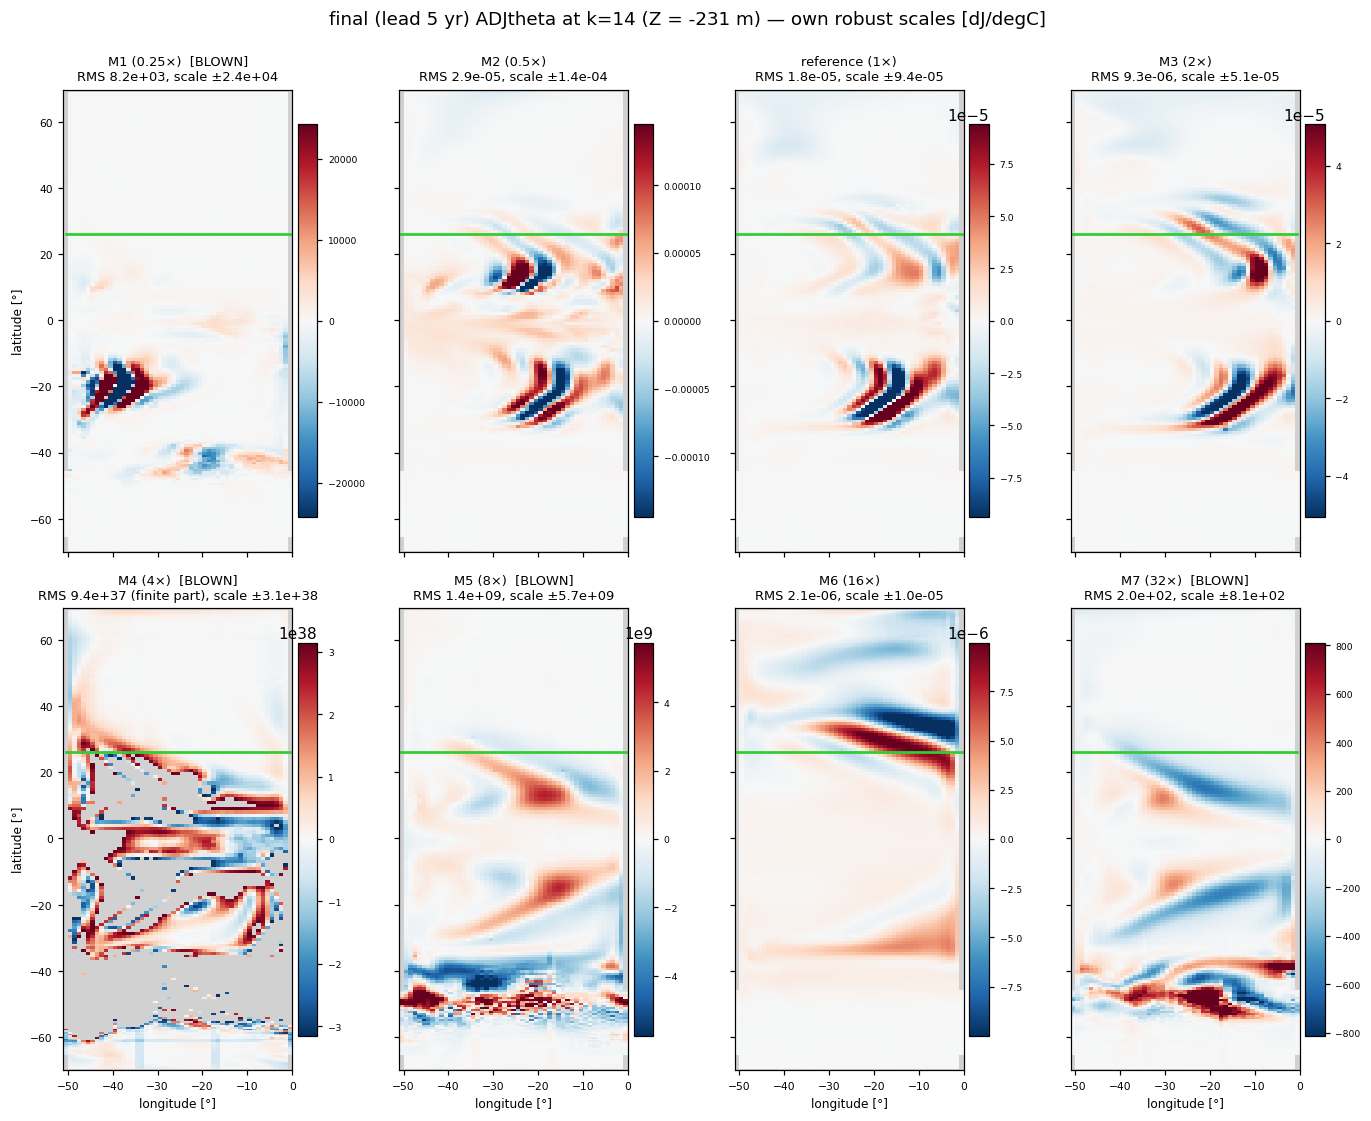

In [3]:
def ensemble_own_scale(var, k, figname):
    fig, axes = plt.subplots(2, 4, figsize=(12.6, 10.2), sharex=True, sharey=True)
    for ax, run in zip(axes.ravel(), ec.RUN_ORDER):
        f = field_at(run, var, k)
        V = ec.robust_sym(f)
        r = wet_rms(f[WET[k]])
        note = " (finite part)" if run == "M4" else ""
        pm = panel(ax, f, V, title=f"{ec.RUNS[run]['label']}"
                                   f"{'' if run in STABLE else '  [BLOWN]' if run != 'M6' else ''}\n"
                                   f"RMS {r:.1e}{note}, scale ±{V:.1e}")
        ec.mark_cost_section(ax)
        cb = fig.colorbar(pm, ax=ax, shrink=0.85, pad=0.02)
        cb.ax.tick_params(labelsize=6)
    for ax in axes[:, 0]:
        ax.set_ylabel("latitude [°]", fontsize=8)
    for ax in axes[1, :]:
        ax.set_xlabel("longitude [°]", fontsize=8)
    fig.suptitle(f"final (lead 5 yr) {var} at k={k} (Z = {G['Z'][k]:.0f} m) — "
                 f"own robust scales [{ec.ADJ_VARS[var]['units']}]", y=0.995)
    fig.tight_layout()
    ec.save_fig(fig, NB_STEM, figname)
    plt.show()

ensemble_own_scale("ADJtheta", 14, "ADJtheta_k14_own_scale")

saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/ADJtheta_k24_own_scale.png


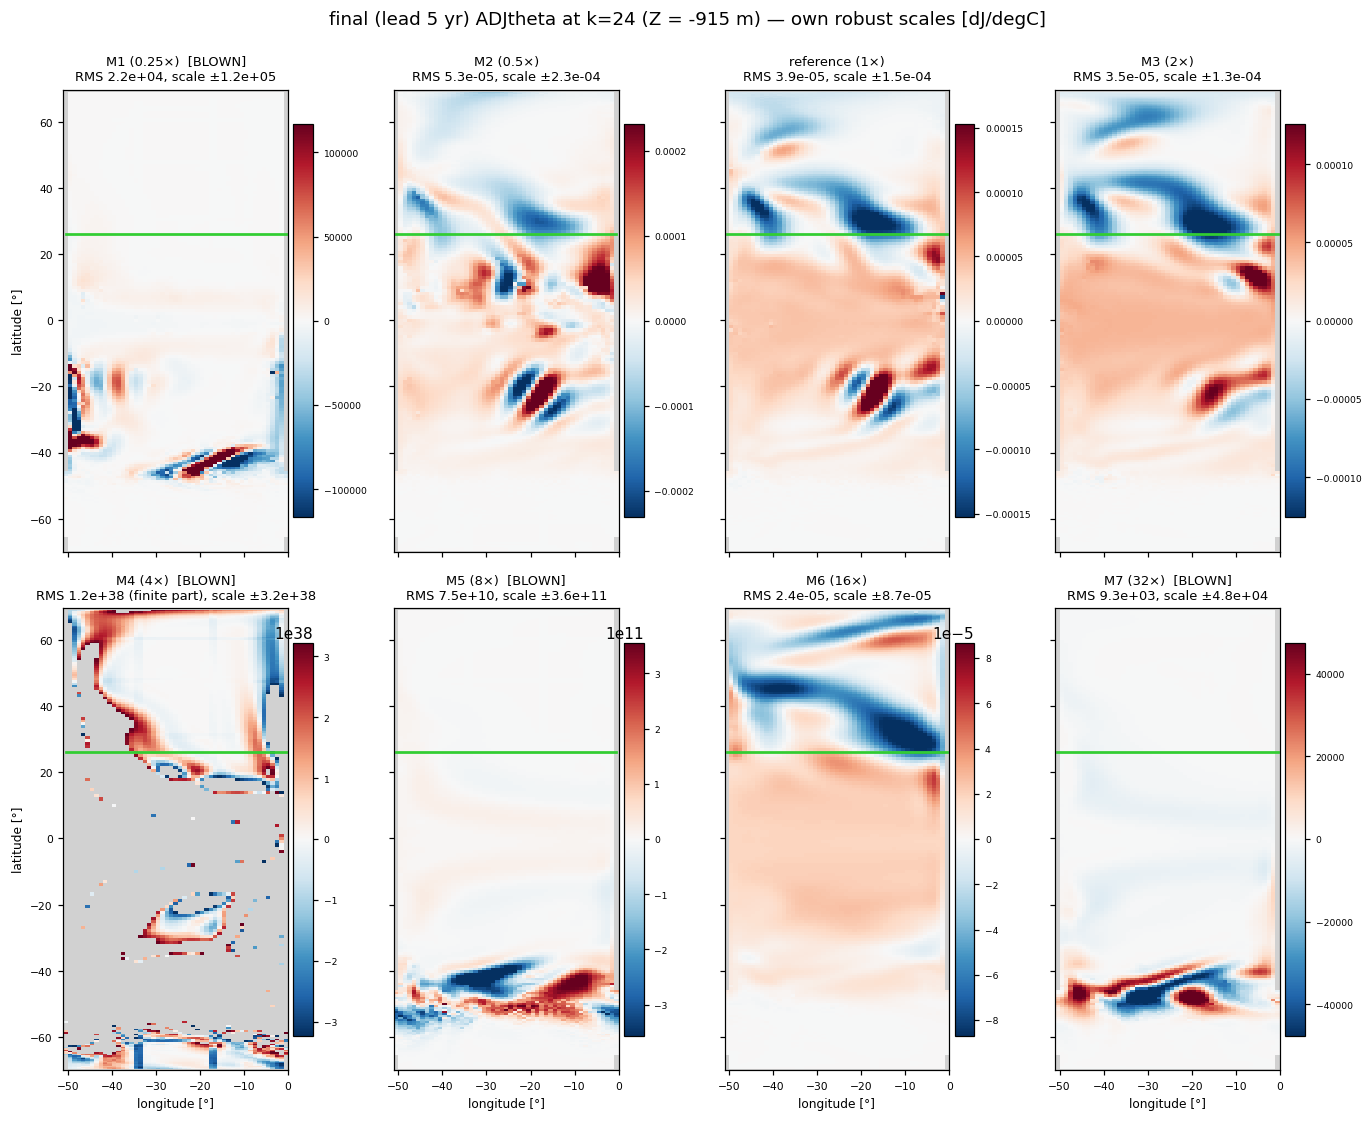

In [4]:
ensemble_own_scale("ADJtheta", 24, "ADJtheta_k24_own_scale")

**Interpretation.** On their own scales, REF, M2 and M3 are near-copies: sensitivity
organised around and upstream (equatorward/westward, following the gyre circulation
back in time) of the 26°N section at k=14, and a stronger, more section-locked signal
at k=24 near the base of the cost integral. M6 still shows the section-locked core but
with visibly more small-scale noise away from it — the map-level counterpart of its
corr 0.435. The four blown members are qualitatively different: their own-scale maps
are dominated by basin-scale noise with amplitudes 10⁴&ndash;10¹¹ (RMS annotations), and the
physically meaningful pattern is invisible beneath it — at this lead nothing of the
signal survives in M1, M4, M5 or M7. M4's grey patches inside the ocean are its
non-finite cells (mapped in section 6).

## 3&nbsp;&nbsp;The same panels on the COMMON reference scale

Same fields, now **clipped at REF's own robust limit** (one shared colorbar). This is
the honest comparison: a member whose sensitivity is physically comparable to REF shows
a similar picture; a blown member saturates the scale everywhere. The per-panel `sat`
annotation is the fraction of finite wet cells beyond the REF limit — for REF itself
~1% by construction (99th-percentile limit).

ADJtheta k=14: REF robust limit ±9.384e-05 dJ/degC
  M1   saturated fraction 100.0%
  M2   saturated fraction   2.0%
  REF  saturated fraction   1.0%
  M3   saturated fraction   0.0%
  M4   saturated fraction 100.0%
  M5   saturated fraction 100.0%
  M6   saturated fraction   0.0%
  M7   saturated fraction 100.0%


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/ADJtheta_k14_ref_scale.png


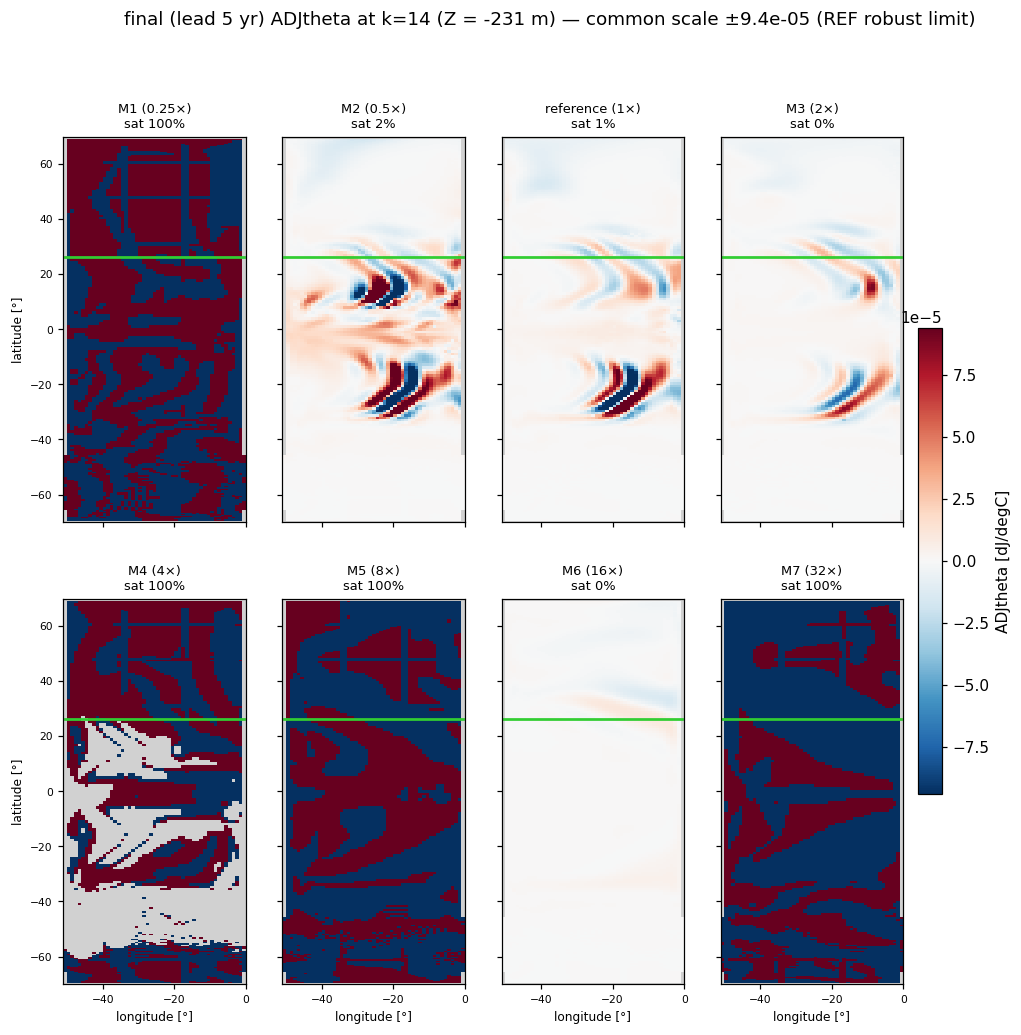

In [5]:
def ensemble_ref_scale(var, k, figname):
    V = ec.robust_sym(field_at("REF", var, k))
    fig, axes = plt.subplots(2, 4, figsize=(11.8, 10.0), sharex=True, sharey=True)
    pm = None
    print(f"{var} k={k}: REF robust limit ±{V:.3e} {ec.ADJ_VARS[var]['units']}")
    for ax, run in zip(axes.ravel(), ec.RUN_ORDER):
        f = field_at(run, var, k)
        fw = f[WET[k]]
        sat = float(np.mean(np.abs(fw[np.isfinite(fw)]) > V))
        pm = panel(ax, f, V, title=f"{ec.RUNS[run]['label']}\nsat {sat:.0%}")
        ec.mark_cost_section(ax)
        print(f"  {run:4s} saturated fraction {sat:6.1%}")
    for ax in axes[:, 0]:
        ax.set_ylabel("latitude [°]", fontsize=8)
    for ax in axes[1, :]:
        ax.set_xlabel("longitude [°]", fontsize=8)
    cb = fig.colorbar(pm, ax=axes.ravel().tolist(), shrink=0.55, pad=0.015)
    cb.set_label(f"{var} [{ec.ADJ_VARS[var]['units']}]")
    fig.suptitle(f"final (lead 5 yr) {var} at k={k} (Z = {G['Z'][k]:.0f} m) — "
                 f"common scale ±{V:.1e} (REF robust limit)", y=0.995)
    ec.save_fig(fig, NB_STEM, figname)
    plt.show()

ensemble_ref_scale("ADJtheta", 14, "ADJtheta_k14_ref_scale")

ADJtheta k=24: REF robust limit ±1.527e-04 dJ/degC
  M1   saturated fraction 100.0%
  M2   saturated fraction   2.8%
  REF  saturated fraction   1.0%
  M3   saturated fraction   0.3%
  M4   saturated fraction 100.0%
  M5   saturated fraction 100.0%
  M6   saturated fraction   0.0%
  M7   saturated fraction 100.0%


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/ADJtheta_k24_ref_scale.png


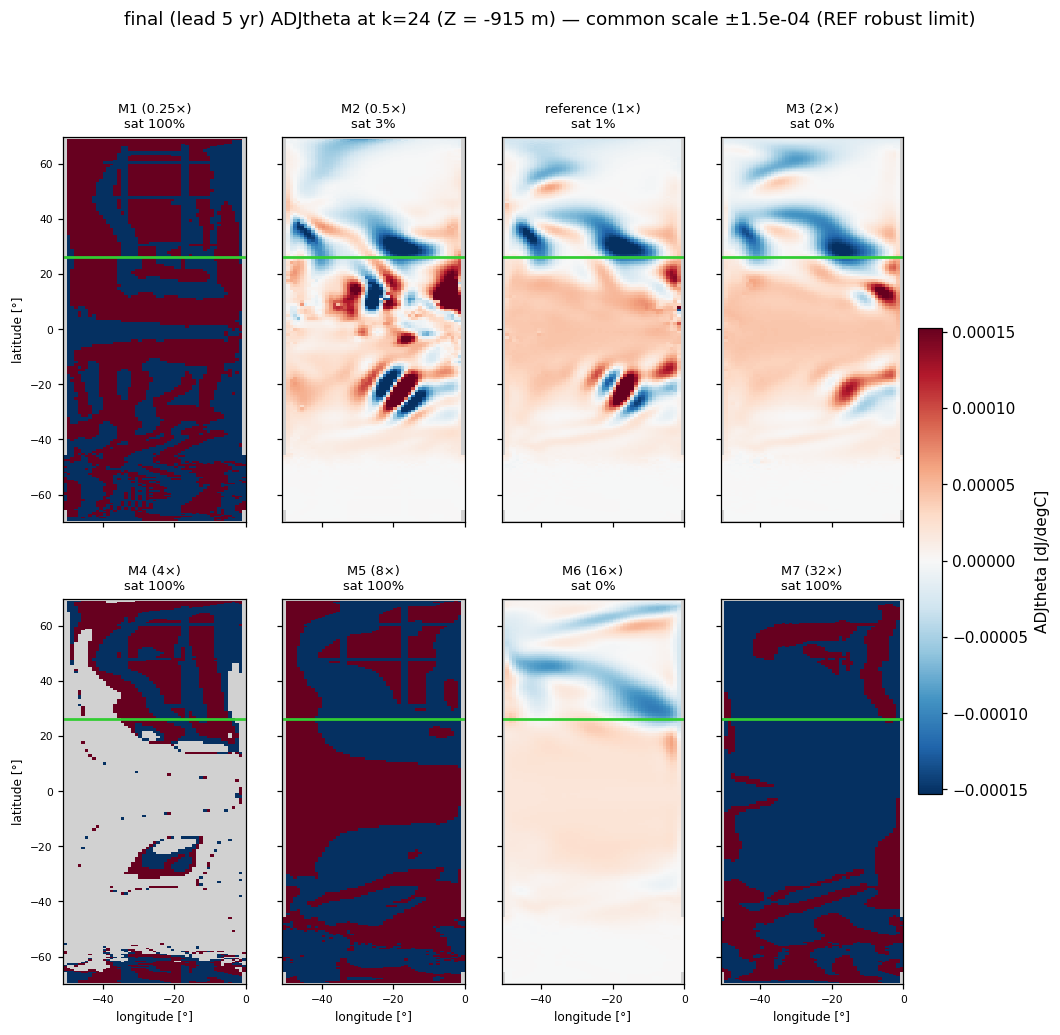

In [6]:
ensemble_ref_scale("ADJtheta", 24, "ADJtheta_k24_ref_scale")

**Interpretation.** On the common scale the classification is visible at a glance:
REF/M2/M3 show the same organised pattern with comparable saturation fractions; M6 is
noticeably *weaker* (its amplitude ratio to REF is ~0.57, so more of its map sits in
the pale mid-range); and the blown members are essentially uniformly saturated — every
finite wet cell beyond the reference limit, carrying no usable pattern at this lead.
The printed saturation fractions quantify this (stable members a few percent to a few
tens of percent, blown members ~100%). Note the blown members' saturation is sign-noise,
not a coherent strong signal: their sign-agreement with REF is ~0.5 (coin flip, section 1
table).

## 4&nbsp;&nbsp;Stable subset in detail: member maps and member − REF differences

For the runs that carry physical signal at lead 5 yr ({M2, REF, M3, M6}), the member
maps and the (member − REF) difference maps, for `ADJtheta` and `ADJdiffkr` at k=14 and
k=24. **All panels of a figure share one scale: REF's robust limit** — so a difference
panel as bright as a member panel means an O(1) relative change of the sensitivity.

To locate where the ensemble differences concentrate, each difference map is summarised
by a *band ratio*: RMS of the difference within ±15 grid rows (~±10.6° latitude) of the
cost section divided by the RMS outside that band. A ratio &gt;1 means the &kappa;
sensitivity of the sensitivity is concentrated near the section.

ADJtheta k=14 (Z=-231 m): difference-concentration band ratio (RMS within ±10.6° of section / outside):
  M2:  2.92   (diff RMS 2.244e-05)
  M3:  1.07   (diff RMS 1.459e-05)
  M6:  0.75   (diff RMS 1.803e-05)


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/stable_ADJtheta_k14.png


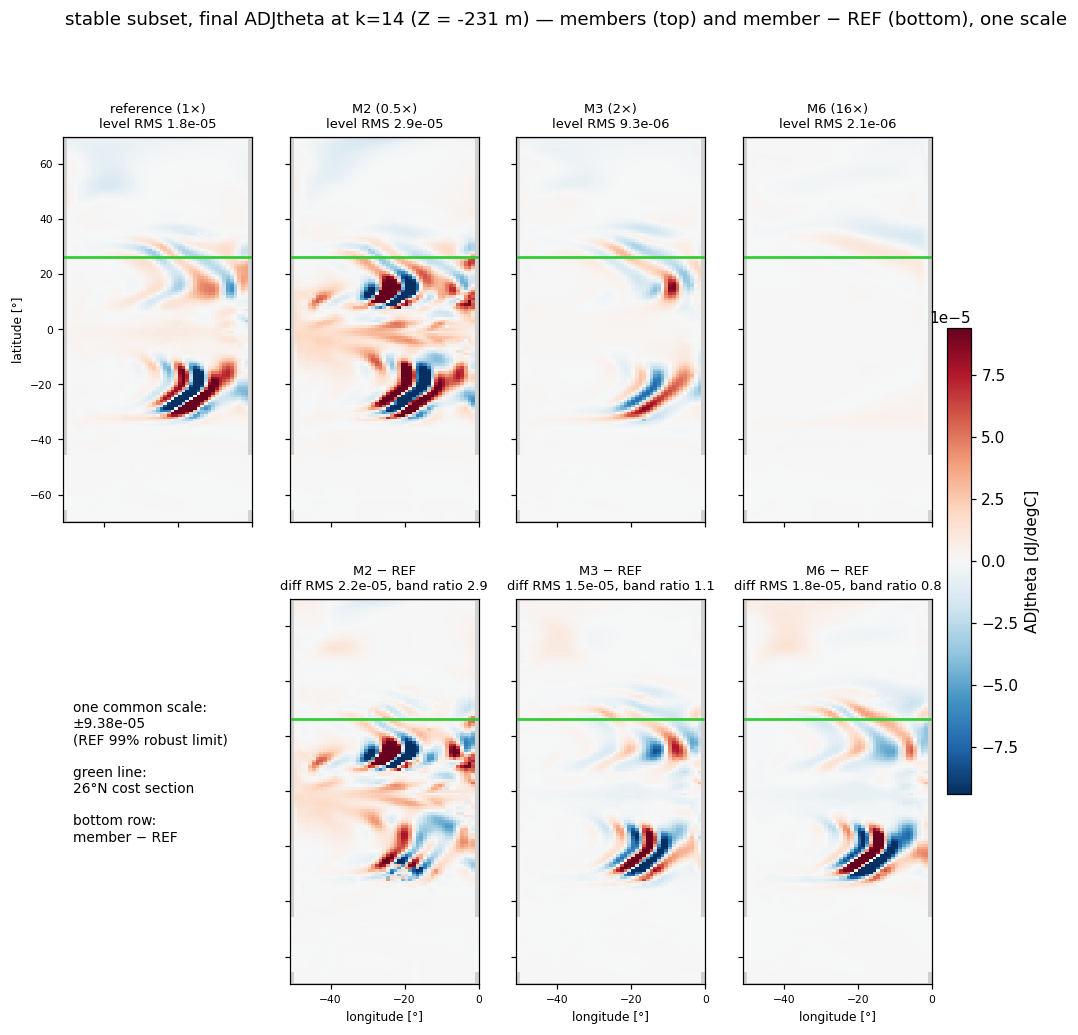

ADJtheta k=24 (Z=-915 m): difference-concentration band ratio (RMS within ±10.6° of section / outside):
  M2:  1.83   (diff RMS 3.865e-05)
  M3:  1.43   (diff RMS 2.214e-05)
  M6:  1.86   (diff RMS 3.526e-05)


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/stable_ADJtheta_k24.png


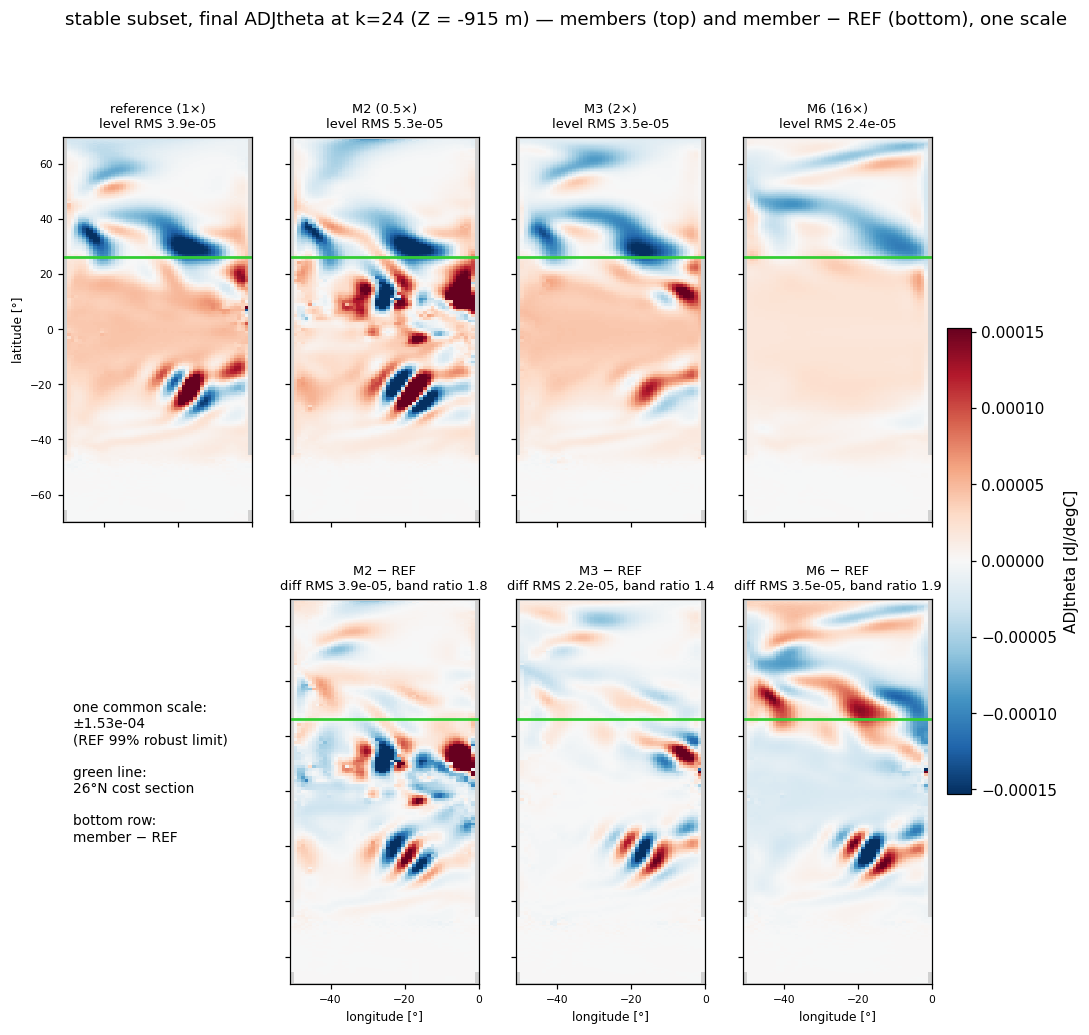

In [7]:
BAND = np.abs(np.arange(WET.shape[1]) - ec.JSEC) <= 15   # +-15 rows ~ +-10.6 deg


def band_ratio(d2, k):
    w = WET[k]
    din = d2[w & BAND[:, None]]
    dout = d2[w & ~BAND[:, None]]
    return wet_rms(din) / wet_rms(dout)


def stable_detail(var, k, figname):
    V = ec.robust_sym(field_at("REF", var, k))
    fig, axes = plt.subplots(2, 4, figsize=(12.2, 10.0), sharex=True, sharey=True)
    pm = None
    for c, run in enumerate(["REF", "M2", "M3", "M6"]):
        f = field_at(run, var, k)
        pm = panel(axes[0, c], f, V,
                   title=f"{ec.RUNS[run]['label']}\nlevel RMS {wet_rms(f[WET[k]]):.1e}")
        ec.mark_cost_section(axes[0, c])
    axes[1, 0].axis("off")
    axes[1, 0].text(0.05, 0.55, f"one common scale:\n±{V:.2e}\n(REF 99% robust limit)\n\n"
                                 "green line:\n26°N cost section\n\n"
                                 "bottom row:\nmember − REF",
                    fontsize=9, va="center", transform=axes[1, 0].transAxes)
    print(f"{var} k={k} (Z={G['Z'][k]:.0f} m): difference-concentration band ratio "
          "(RMS within ±10.6° of section / outside):")
    for c, run in enumerate(["M2", "M3", "M6"], start=1):
        d = field_at(run, var, k) - field_at("REF", var, k)
        br = band_ratio(d, k)
        panel(axes[1, c], d, V,
              title=f"{run} − REF\ndiff RMS {wet_rms(d[WET[k]]):.1e}, band ratio {br:.1f}")
        ec.mark_cost_section(axes[1, c])
        print(f"  {run}: {br:5.2f}   (diff RMS {wet_rms(d[WET[k]]):.3e})")
    for ax in axes[:, 0]:
        ax.set_ylabel("latitude [°]", fontsize=8)
    for ax in axes[1, 1:]:
        ax.set_xlabel("longitude [°]", fontsize=8)
    cb = fig.colorbar(pm, ax=axes.ravel().tolist(), shrink=0.55, pad=0.015)
    cb.set_label(f"{var} [{ec.ADJ_VARS[var]['units']}]")
    fig.suptitle(f"stable subset, final {var} at k={k} (Z = {G['Z'][k]:.0f} m) — "
                 f"members (top) and member − REF (bottom), one scale", y=0.995)
    ec.save_fig(fig, NB_STEM, figname)
    plt.show()

stable_detail("ADJtheta", 14, "stable_ADJtheta_k14")
stable_detail("ADJtheta", 24, "stable_ADJtheta_k24")

ADJdiffkr k=14 (Z=-231 m): difference-concentration band ratio (RMS within ±10.6° of section / outside):
  M2:  2.46   (diff RMS 4.168e-02)
  M3:  2.47   (diff RMS 4.087e-02)
  M6:  1.53   (diff RMS 3.657e-02)


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/stable_ADJdiffkr_k14.png


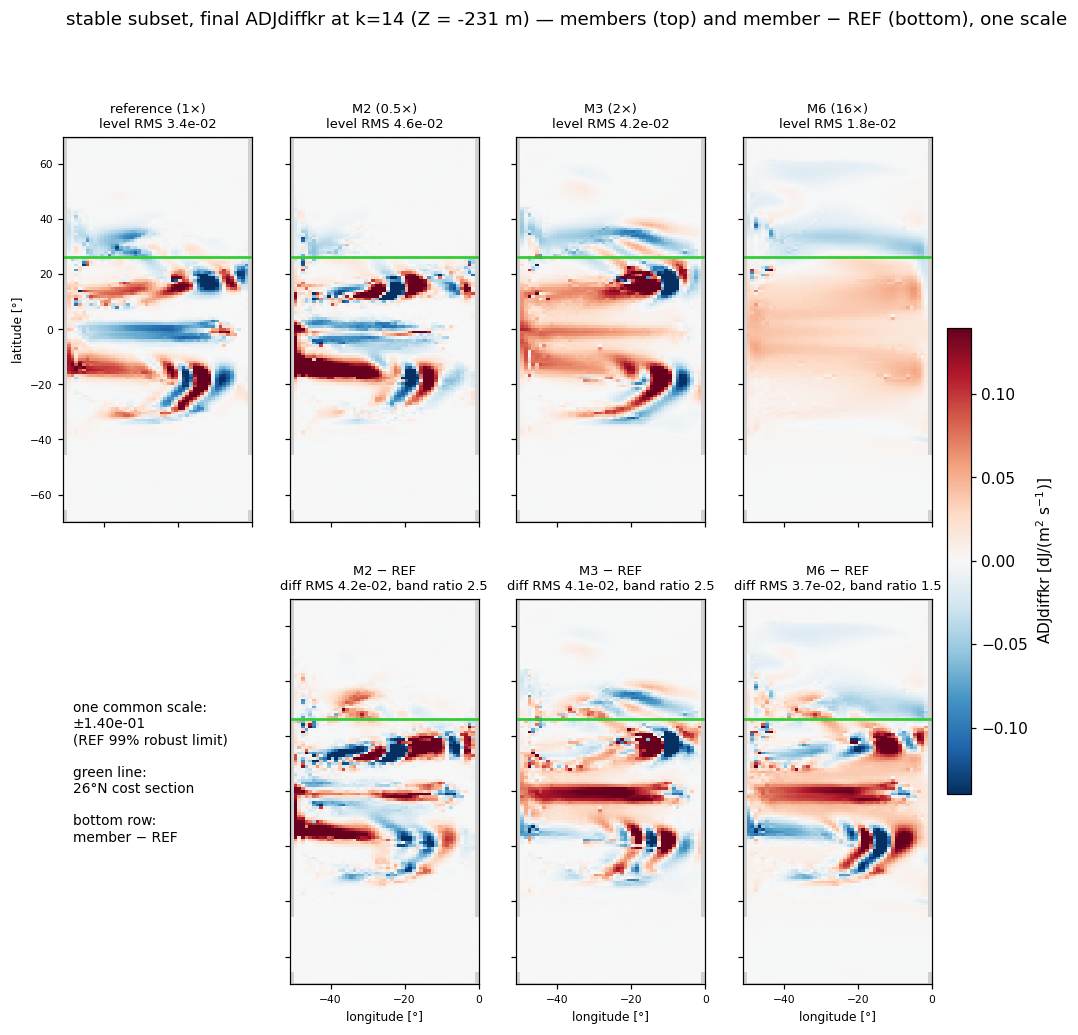

ADJdiffkr k=24 (Z=-915 m): difference-concentration band ratio (RMS within ±10.6° of section / outside):
  M2:  4.32   (diff RMS 6.358e-02)
  M3: 10.13   (diff RMS 7.242e-02)
  M6: 15.65   (diff RMS 1.530e-01)


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/stable_ADJdiffkr_k24.png


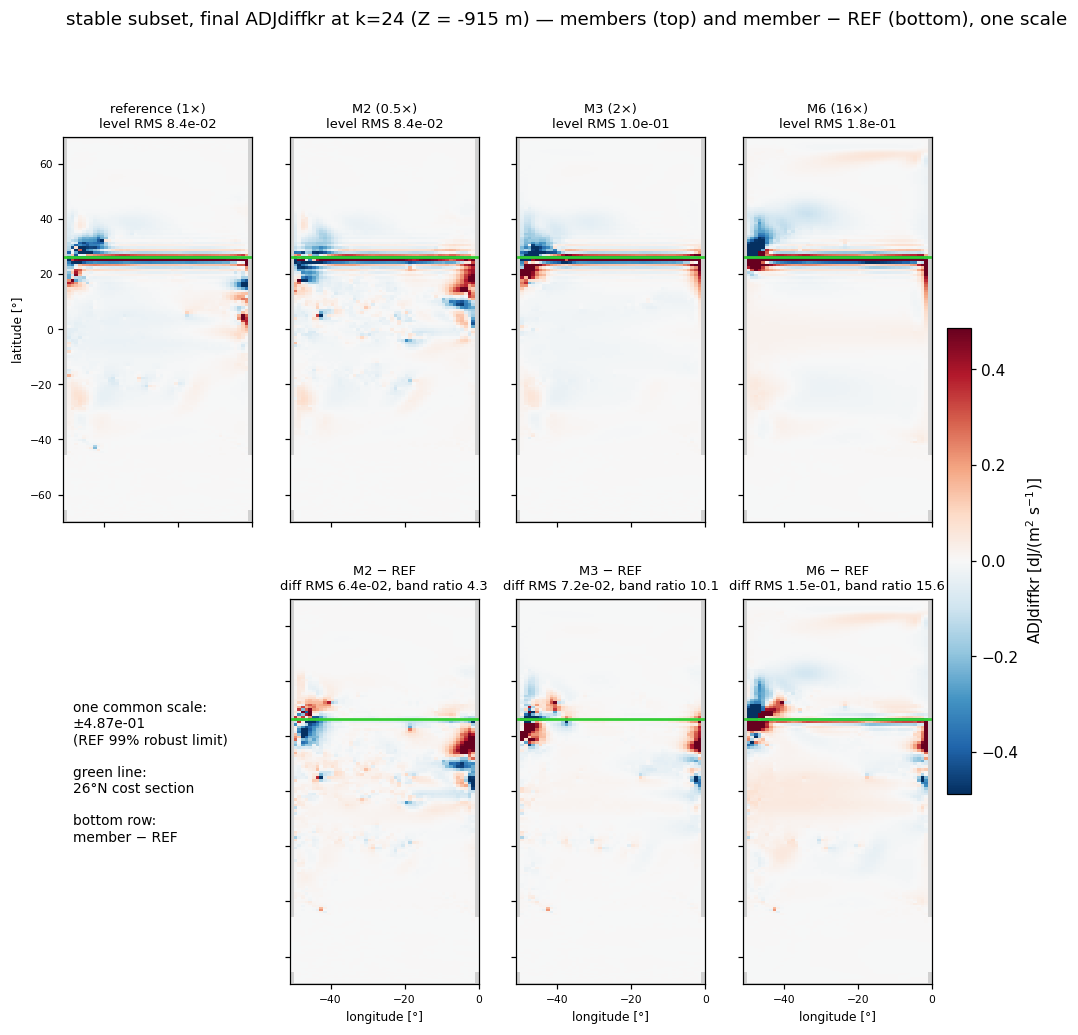

In [8]:
stable_detail("ADJdiffkr", 14, "stable_ADJdiffkr_k14")
stable_detail("ADJdiffkr", 24, "stable_ADJdiffkr_k24")

**Where do the differences concentrate?** The band ratios split cleanly by variable and
depth:

- **`ADJdiffkr` differences are section-locked, increasingly so at depth**: band ratios
  ~1.5&ndash;2.5 at k=14 and ~4&ndash;16 at k=24 (M6 largest). Changing &kappa; changes the
  &kappa;-sensitivity mostly right at the cost section, in the depth range of the cost
  integral — where the direct terminal-month forcing enters.
- **`ADJtheta` differences are much less localised.** At k=24 all three members
  concentrate moderately near the section (ratios ~1.4&ndash;1.9); at k=14 only M2 does
  (~2.9), while M3 is basin-wide (~1.1) and M6's differences are actually *larger away
  from the section* (~0.75) — consistent with M6's degradation being incipient
  broad-band adjoint noise rather than a physical &kappa; response.

The amplitude asymmetry between M2 and M3 is also visible: M2 (0.5&times;) *strengthens* the
sensitivity relative to REF (bright difference map, amp ratio ~1.37) while M3 (2&times;)
*weakens* it (~0.77) — higher background diffusivity damps the adjoint signal, as it
damps the forward anomalies it linearises around. Notebook 04 quantifies this
magnitude-vs-structure split per variable, depth and lead.

## 5&nbsp;&nbsp;The surrogate's target: vertically summed dJ/d&kappa; maps

The control gradient `adxx_diffkr` is the field a &kappa;-input NN surrogate would have to
predict (master plan Part II). Summed vertically it gives the map of
&part;J/&part;&kappa;(column): the response of J to raising &kappa; uniformly over one water
column. Summed over the whole domain it gives dJ/d(uniform &kappa;) — the single number the
dJ decomposition in notebook 01 uses as its direct-&kappa; term. Shown for the stable runs
only (a blown run's gradient is garbage — notebook 01's `dJ_kappa_bwd` column), on one
common diverging scale, with member − REF differences below.

domain-summed dJ/d(uniform kappa)  [dJ per m^2 s^-1]:
  REF  (   1x):    -435.6
  M2   ( 0.5x):    -251.3
  M3   (   2x):     -77.9
  M6   (  16x):    +673.3


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/adxx_diffkr_vertsum_stable.png


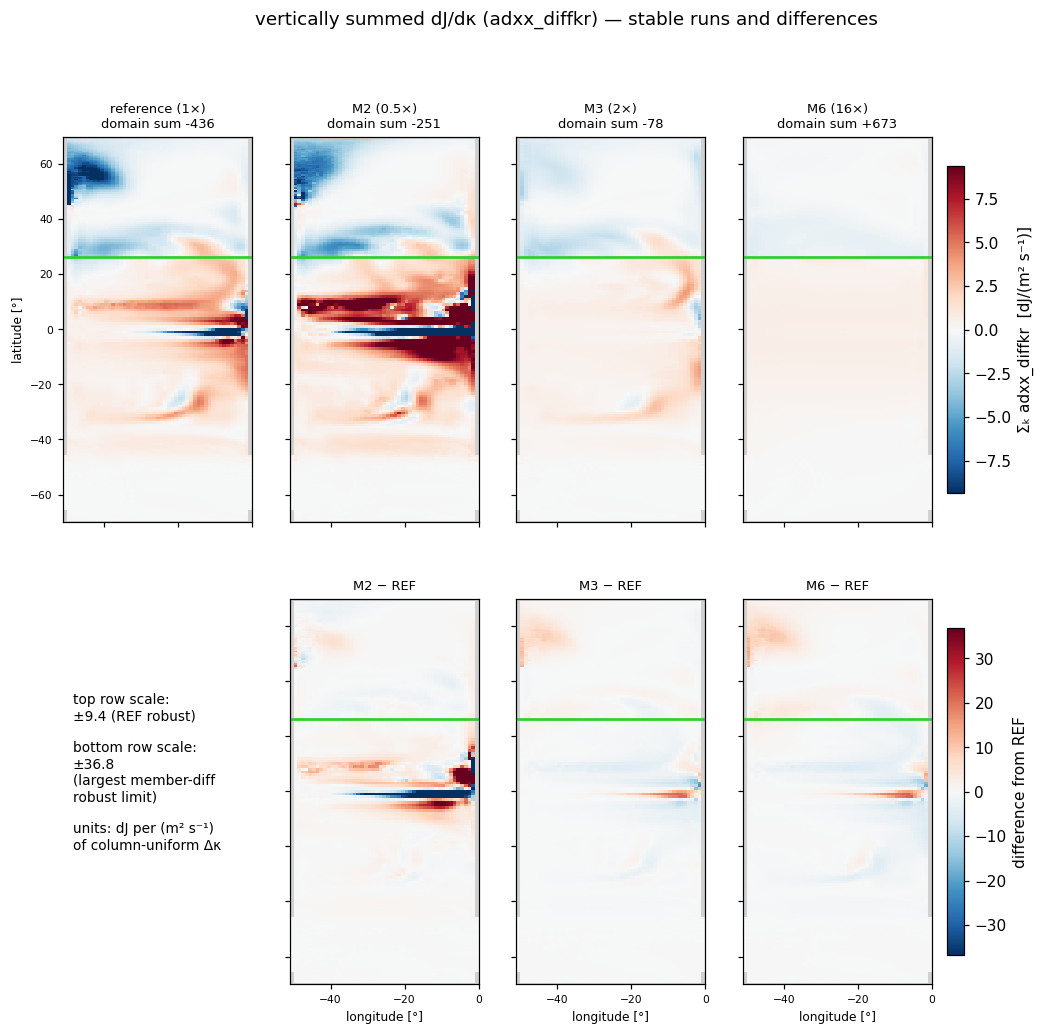

In [9]:
def vertsum_dkr(run):
    a = ADXX3.field.sel(run=run, var="adxx_diffkr").values
    a = np.where(WET, a, 0.0).sum(axis=0)
    return np.where(WET.any(axis=0), a, np.nan)


V = ec.robust_sym(vertsum_dkr("REF"))
diffs = {r: vertsum_dkr(r) - vertsum_dkr("REF") for r in ["M2", "M3", "M6"]}
Vd = max(ec.robust_sym(d) for d in diffs.values())

fig, axes = plt.subplots(2, 4, figsize=(12.2, 10.0), sharex=True, sharey=True)
print("domain-summed dJ/d(uniform kappa)  [dJ per m^2 s^-1]:")
pm_top = None
for c, run in enumerate(["REF", "M2", "M3", "M6"]):
    vs = vertsum_dkr(run)
    tot = np.nansum(vs)
    pm_top = panel(axes[0, c], vs, V,
                   title=f"{ec.RUNS[run]['label']}\ndomain sum {tot:+.0f}")
    ec.mark_cost_section(axes[0, c])
    print(f"  {run:4s} ({ec.RUNS[run]['factor']:4g}x): {tot:+9.1f}")
axes[1, 0].axis("off")
axes[1, 0].text(0.05, 0.55, f"top row scale:\n±{V:.1f} (REF robust)\n\n"
                             f"bottom row scale:\n±{Vd:.1f}\n(largest member-diff\nrobust limit)\n\n"
                             "units: dJ per (m² s⁻¹)\nof column-uniform Δκ",
                fontsize=9, va="center", transform=axes[1, 0].transAxes)
pm_bot = None
for c, run in enumerate(["M2", "M3", "M6"], start=1):
    pm_bot = panel(axes[1, c], diffs[run], Vd, title=f"{run} − REF")
    ec.mark_cost_section(axes[1, c])
for ax in axes[:, 0]:
    ax.set_ylabel("latitude [°]", fontsize=8)
for ax in axes[1, 1:]:
    ax.set_xlabel("longitude [°]", fontsize=8)
cb1 = fig.colorbar(pm_top, ax=axes[0, :].tolist(), shrink=0.85, pad=0.015)
cb1.set_label("Σₖ adxx_diffkr  [dJ/(m² s⁻¹)]")
cb2 = fig.colorbar(pm_bot, ax=axes[1, :].tolist(), shrink=0.85, pad=0.015)
cb2.set_label("difference from REF")
fig.suptitle("vertically summed dJ/dκ (adxx_diffkr) — stable runs and differences",
             y=0.995)
ec.save_fig(fig, NB_STEM, "adxx_diffkr_vertsum_stable")
plt.show()

**Interpretation.** The dJ/d&kappa; map itself is strongly &kappa;-dependent — this is the
key hand-off to the surrogate discussion. The domain-integrated gradient goes from
−251 (M2, 0.5&times;) through **−436 (REF)** to −78 (M3, 2&times;), and *flips sign* to +673 at
M6 (16&times;, degraded — trust it only qualitatively). So even inside the stable range a
factor-2 change of &kappa; changes the integrated gradient by a factor of a few: a
linear-in-&kappa; extrapolation of the gradient has no useful trust radius here, matching
notebook 01's finding that the linear prediction of &Delta;J fails at every tested
&Delta;&kappa;. Note also the sign: the in-window direct effect of raising &kappa; uniformly is
*negative* (REF −436, i.e. J drops), while the measured member fc *increases* with
&kappa; — the measured curve is dominated by the 10-yr forward state adjustment, which the
5-yr-window gradient cannot see (notebook 01's decomposition). Spatially the maps agree
where they matter most: a strong negative lobe along and just south of the section with
positive bands flanking it — the difference maps show the same section-locked structure
growing with |&Delta;&kappa;| (band ratios above).

## 6&nbsp;&nbsp;Anatomy of the blown members

What does a blown adjoint actually look like at lead 5 yr? Shown as **log₁₀|ADJtheta|**
at k=14 for M1, M5, M7 (each on its own log range, 1st&ndash;99th percentile; REF leftmost
for magnitude context), plus M4's non-finite geography. The printed percentile spread
answers "is the blow-up localised (a seed region) or domain-filling by lead 5 yr?" —
the time evolution itself (when each member departs, where the instability seeds) is
notebook 06's job, via `timeseries_stats.nc` and the M5 blow-up animation.

log10|final ADJtheta| at k=14, wet cells (zeros excluded):
  REF : p1   -9.3   p50   -6.1   p99   -4.0   fraction within 3 decades of p99: 0.75
  M1  : p1   -1.7   p50    1.2   p99    4.4   fraction within 3 decades of p99: 0.45
  M5  : p1    5.6   p50    8.2   p99    9.8   fraction within 3 decades of p99: 0.88
  M7  : p1   -1.5   p50    1.3   p99    2.9   fraction within 3 decades of p99: 0.85


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/blown_log10_ADJtheta_k14.png


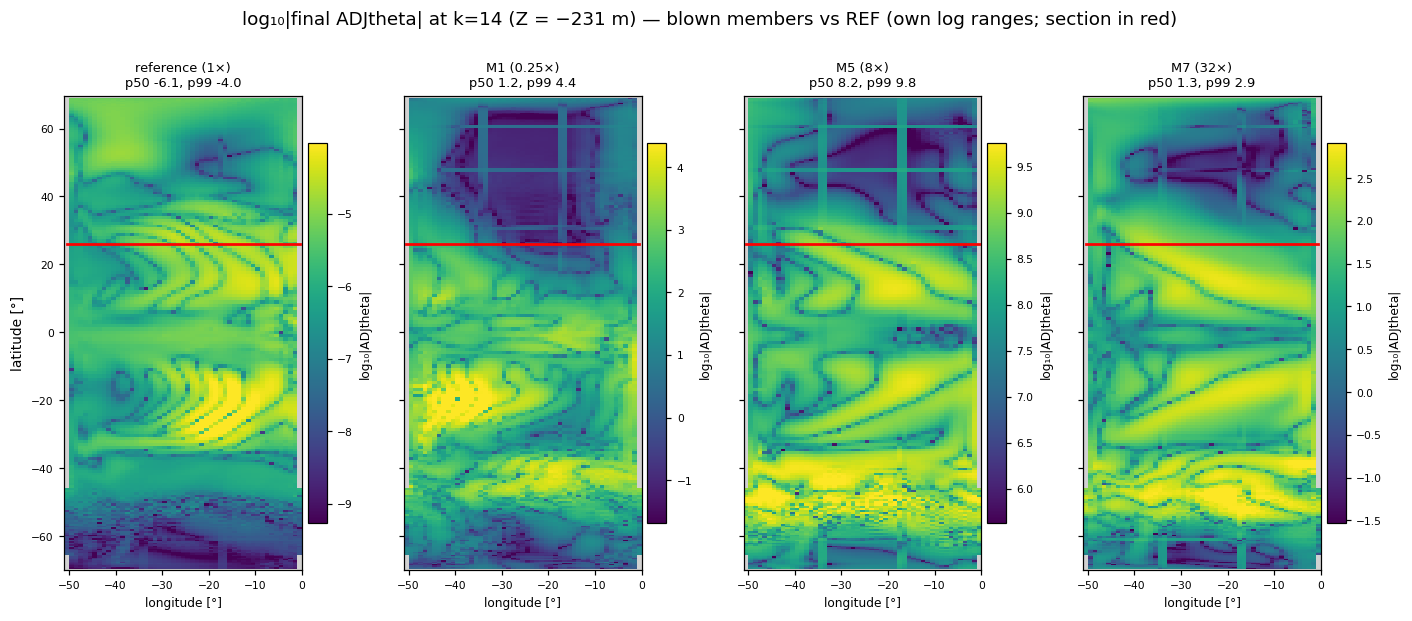

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(13.0, 5.6), sharey=True)
print("log10|final ADJtheta| at k=14, wet cells (zeros excluded):")
for ax, run in zip(axes, ["REF", "M1", "M5", "M7"]):
    f = np.abs(field_at(run, "ADJtheta", 14))
    l = np.where(f > 0, np.log10(f), np.nan)
    fin = l[np.isfinite(l)]
    lo, hi = np.percentile(fin, [1, 99])
    within3 = float(np.mean(fin > hi - 3))
    pm = panel(ax, l, vmax=hi, vmin=lo, cmap="viridis",
               title=f"{ec.RUNS[run]['label']}\np50 {np.percentile(fin, 50):.1f}, "
                     f"p99 {hi:.1f}")
    ec.mark_cost_section(ax, color="red")
    cb = fig.colorbar(pm, ax=ax, shrink=0.8, pad=0.02)
    cb.ax.tick_params(labelsize=7)
    cb.set_label("log₁₀|ADJtheta|", fontsize=8)
    print(f"  {run:4s}: p1 {np.percentile(fin, 1):6.1f}   p50 {np.percentile(fin, 50):6.1f}   "
          f"p99 {hi:6.1f}   fraction within 3 decades of p99: {within3:.2f}")
axes[0].set_ylabel("latitude [°]", fontsize=9)
for ax in axes:
    ax.set_xlabel("longitude [°]", fontsize=8)
fig.suptitle("log₁₀|final ADJtheta| at k=14 (Z = −231 m) — blown members vs REF "
             "(own log ranges; section in red)", y=1.0)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "blown_log10_ADJtheta_k14")
plt.show()

M4 final ADJtheta: 124042 of 332274 wet cells non-finite (37.3%)
  columns with >=1 non-finite level: 7344 of 9627 (76.3%)
  at k=14: 2736 of 9627 (28.4%)
  non-finite fraction of wet cells south of 40°S: 50.7%
  non-finite fraction of wet cells 40°S–40°N: 46.3%
  non-finite fraction of wet cells north of 40°N: 8.5%


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/M4_nonfinite_maps.png


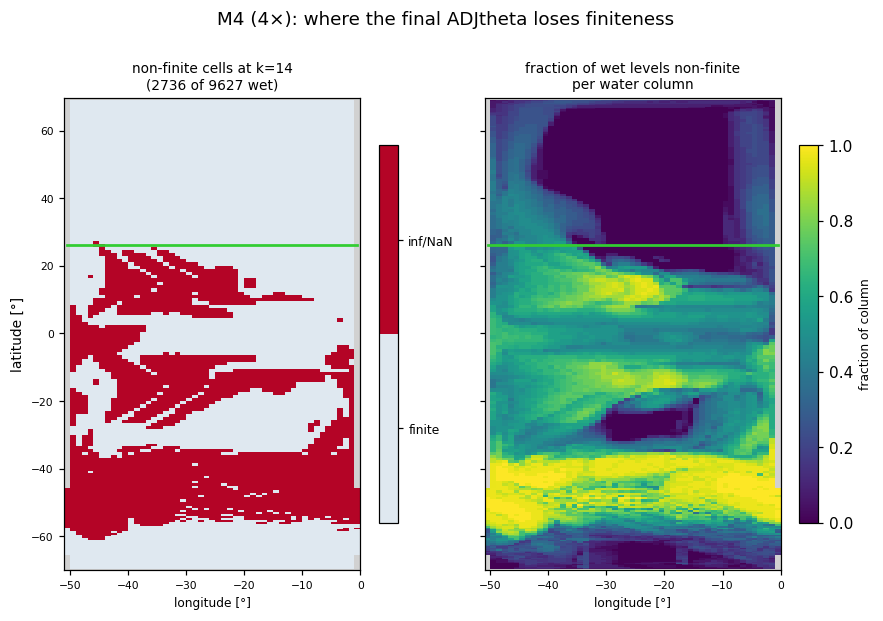

In [11]:
# M4 — the only run that loses finiteness: where do the inf/NaN cells sit?
m4 = FINAL3.field.sel(run="M4", var="ADJtheta").values
nonfin = ~np.isfinite(m4) & WET
n_nf = int(nonfin.sum())
n_wet = int(WET.sum())
cols_nf = int(nonfin.any(axis=0).sum())
cols_wet = int(WET.any(axis=0).sum())
print(f"M4 final ADJtheta: {n_nf} of {n_wet} wet cells non-finite ({n_nf / n_wet:.1%})")
print(f"  columns with >=1 non-finite level: {cols_nf} of {cols_wet} ({cols_nf / cols_wet:.1%})")
print(f"  at k=14: {int(nonfin[14].sum())} of {int(WET[14].sum())} "
      f"({nonfin[14].sum() / WET[14].sum():.1%})")
yc1 = G["YC"][:, 25]
for name, sel in [("south of 40°S", yc1 < -40), ("40°S–40°N", (yc1 >= -40) & (yc1 <= 40)),
                  ("north of 40°N", yc1 > 40)]:
    frac = nonfin[:, sel, :].sum() / max(WET[:, sel, :].sum(), 1)
    print(f"  non-finite fraction of wet cells {name}: {frac:.1%}")

from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(8.2, 5.6), sharey=True)
binmap = np.where(WET[14], nonfin[14].astype(float), np.nan)
cmo = ListedColormap(["#dfe8f0", "#b40426"])
cmo.set_bad("0.82")
pm0 = axes[0].pcolormesh(G["XC"], G["YC"], binmap, cmap=cmo, vmin=0, vmax=1,
                         shading="auto", rasterized=True)
axes[0].set_title(f"non-finite cells at k=14\n({int(nonfin[14].sum())} of "
                  f"{int(WET[14].sum())} wet)", fontsize=9)
cb0 = fig.colorbar(pm0, ax=axes[0], shrink=0.8, ticks=[0.25, 0.75])
cb0.ax.set_yticklabels(["finite", "inf/NaN"], fontsize=8)
fracmap = np.where(WET.any(axis=0),
                   nonfin.sum(axis=0) / np.maximum(WET.sum(axis=0), 1), np.nan)
cmv = plt.get_cmap("viridis").copy()
cmv.set_bad("0.82")
pm1 = axes[1].pcolormesh(G["XC"], G["YC"], fracmap, cmap=cmv, vmin=0, vmax=1,
                         shading="auto", rasterized=True)
axes[1].set_title("fraction of wet levels non-finite\nper water column", fontsize=9)
cb1 = fig.colorbar(pm1, ax=axes[1], shrink=0.8)
cb1.set_label("fraction of column", fontsize=8)
for ax in axes:
    ec.mark_cost_section(ax)
    ax.grid(False)
    ax.tick_params(labelsize=7)
    ax.set_xlabel("longitude [°]", fontsize=8)
axes[0].set_ylabel("latitude [°]", fontsize=9)
fig.suptitle("M4 (4×): where the final ADJtheta loses finiteness", y=1.0)
fig.tight_layout()
ec.save_fig(fig, NB_STEM, "M4_nonfinite_maps")
plt.show()

**Interpretation.** By lead 5 yr the blow-up is **domain-filling in every blown member,
but with tell-tale structure**:

- **M5 (8&times;)** is the most homogeneous: 88% of wet k=14 cells within 3 decades of the
  99th percentile (median |ADJtheta| ~10⁸) — the instability has saturated the whole
  basin. **M7 (32&times;)** is similar in flatness (85% within 3 decades) at a lower
  amplitude (median ~10¹), consistent with 32&times; diffusivity damping the noise even as
  the linearised dynamics stay unstable.
- **M1 (0.25&times;)** is the interesting one: a ~6-decade spread (p1 ~10⁻¹·⁷ to p99 ~10⁴·⁴,
  only 45% within 3 decades of p99) — its map still has amplitude *structure*, i.e. the
  blow-up has strong regional maxima rather than uniform saturation. This matches its
  late departure (its pattern correlation with REF survives to lead ~2.5 yr, section 7):
  the instability had less time to spread than in M5/M7.
- **M4 (4&times;)** went beyond overflow into non-finite arithmetic: 37.3% of wet cells
  inf/NaN, spread over 76.3% of water columns — but strongly latitude-organised:
  ~51% of wet cells south of 40°S and ~46% in 40°S&ndash;40°N are non-finite against only
  ~8.5% north of 40°N. The non-finite region (where float32 overflow occurred first)
  spares most of the northern basin, pointing to a Southern-Ocean/tropical seed of the
  worst instability. Notebook 06 resolves the timing (`finite_frac` vs lead) and shows
  the M5 blow-up spreading in animation.

## 7&nbsp;&nbsp;Usable lead-time windows — the hand-off to notebooks 04/05/06

A blown member is not useless: the adjoint fills its dumps *backwards* (last dump in
forward time is computed first), so short leads are computed early in the reverse sweep,
**before** the instability grows. Each member therefore has a usable window
[0, L<sub>max</sub>] of lead times over which its sensitivity still tracks REF.

Quantified here from the cached per-dump pattern correlation with REF
(`member_metrics_time.nc`, `ADJtheta`, volume-weighted): for thresholds 0.9 / 0.8 / 0.5,
the **sustained lead** = the largest lead L such that corr &ge; threshold at *every* dump
with lead &le; L (first-crossing rule, scanning from short leads upward — robust against
the corr wiggling back above the threshold later). The table is also written to
`stats/` for reuse by the other notebooks.

,kappa_factor,corr_at_lead5,classification,sustained_lead_corr_ge_0.9,sustained_lead_corr_ge_0.8,sustained_lead_corr_ge_0.5
member,,,,,,
M1,0.25,-0.011,blown,0.11,0.18,2.53
M2,0.5,+0.818,stable,0.16,0.29,5.00
M3,2,+0.845,stable,0.19,0.38,5.00
M4,4,+0.031,blown,0.12,0.23,0.70
M5,8,-0.019,blown,0.11,0.18,1.26
M6,16,+0.493,degraded,0.08,0.12,2.64
M7,32,+0.006,blown,0.07,0.08,0.33


written /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/stats/03_usable_lead_ADJtheta_volume_weighted.csv

pattern corr vs REF (ADJtheta, volume-weighted) at selected leads [yr]:
lead:    0.01   0.08   0.25   0.51   1.00   1.50   1.99   2.50   3.01   4.00   5.00
M1:    +0.98  +0.96  +0.71  +0.60  +0.60  +0.72  +0.77  +0.77  -0.01  +0.00  -0.01
M2:    +0.99  +0.98  +0.84  +0.76  +0.76  +0.84  +0.87  +0.88  +0.88  +0.84  +0.82
M3:    +1.00  +0.99  +0.88  +0.82  +0.69  +0.81  +0.86  +0.85  +0.84  +0.82  +0.85
M4:    +0.99  +0.99  +0.78  +0.70  -0.01  +0.00  -0.01  +0.00  -0.00  -0.05  +0.03
M5:    +0.99  +0.97  +0.70  +0.64  +0.59  +0.37  -0.00  -0.01  -0.02  -0.01  -0.02
M6:    +0.97  +0.95  +0.62  +0.58  +0.51  +0.53  +0.52  +0.50  +0.49  +0.47  +0.49
M7:    +0.92  +0.89  +0.55  +0.01  +0.01  -0.00  -0.01  -0.00  +0.00  -0.01  +0.01


saved /scratch2/tshahriar/DINO_1deg_tapAdj_runs/kappa_v_ensemble_analysis/figures/03_ensemble_sensitivity_maps/corr_vs_lead_ADJtheta.png


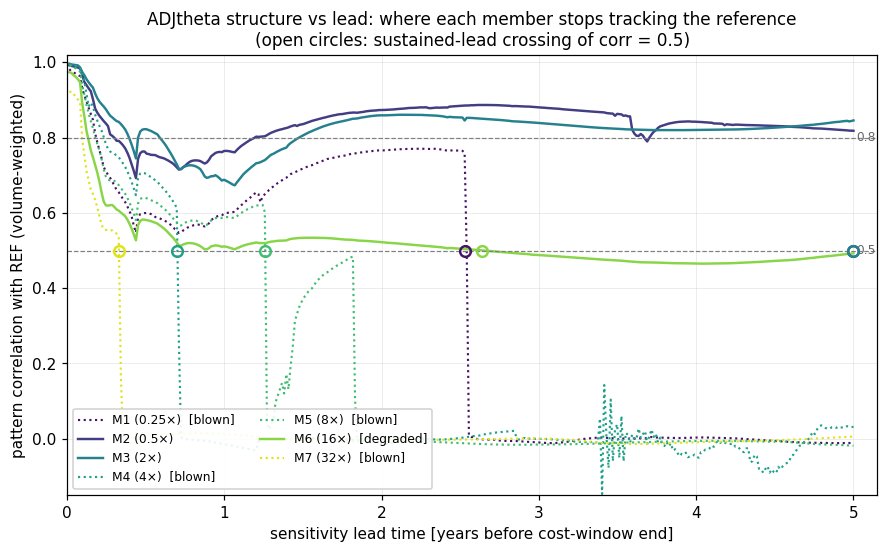

In [12]:
corr_t = MMT.corr.sel(var="ADJtheta", weighting="volume")
lead_all = MMT.lead_years.values
order = np.argsort(lead_all)
ls = lead_all[order]

rows = []
for mem in ec.MEMBERS:
    c = corr_t.sel(member=mem).values[order]
    rec = dict(member=mem, kappa_factor=ec.RUNS[mem]["factor"],
               corr_at_lead5=c[-1],
               classification=("stable" if mem in STABLE and mem != "M6"
                               else "degraded" if mem == "M6" else "blown"))
    for thr in (0.9, 0.8, 0.5):
        below = np.where(c < thr)[0]
        L = (ls[-1] if below.size == 0
             else (ls[below[0] - 1] if below[0] > 0 else 0.0))
        rec[f"sustained_lead_corr_ge_{thr}"] = L
    rows.append(rec)
usable = pd.DataFrame(rows).set_index("member")
display(usable.style.format({"corr_at_lead5": "{:+.3f}", "kappa_factor": "{:g}",
                             "sustained_lead_corr_ge_0.9": "{:.2f}",
                             "sustained_lead_corr_ge_0.8": "{:.2f}",
                             "sustained_lead_corr_ge_0.5": "{:.2f}"}))

ec.STATS_ROOT.mkdir(parents=True, exist_ok=True)
csv_path = ec.STATS_ROOT / "03_usable_lead_ADJtheta_volume_weighted.csv"
usable.to_csv(csv_path)
print(f"written {csv_path}")

# corr at a few reference leads, for the record
picks = [0.014, 0.082, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]
idx = [int(np.abs(ls - p).argmin()) for p in picks]
print("\npattern corr vs REF (ADJtheta, volume-weighted) at selected leads [yr]:")
print("lead:  " + " ".join(f"{ls[i]:6.2f}" for i in idx))
for mem in ec.MEMBERS:
    c = corr_t.sel(member=mem).values[order]
    print(f"{mem}:   " + " ".join(f"{c[i]:+6.2f}" for i in idx))

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for mem in ec.MEMBERS:
    c = corr_t.sel(member=mem).values[order]
    kw = ec.line_kwargs(mem)
    if mem not in STABLE:
        kw.update(ls=":", lw=1.4)
        kw["label"] += "  [blown]"
    elif mem == "M6":
        kw["label"] += "  [degraded]"
    ax.plot(ls, c, **kw)
    L05 = usable.loc[mem, "sustained_lead_corr_ge_0.5"]
    ax.plot([L05], [0.5], marker="o", mfc="none", mec=ec.member_color(mem),
            ms=7, mew=1.6, ls="none", zorder=6)
for thr, lab in [(0.8, "0.8"), (0.5, "0.5")]:
    ax.axhline(thr, color="0.5", lw=0.8, ls="--")
    ax.text(5.02, thr, lab, fontsize=8, color="0.4", va="center")
ax.set_xlim(0, 5.15)
ax.set_ylim(-0.15, 1.02)
ax.set_xlabel("sensitivity lead time [years before cost-window end]")
ax.set_ylabel("pattern correlation with REF (volume-weighted)")
ax.set_title("ADJtheta structure vs lead: where each member stops tracking the "
             "reference\n(open circles: sustained-lead crossing of corr = 0.5)")
ax.legend(ncol=2, fontsize=8, loc="lower left")
ec.save_fig(fig, NB_STEM, "corr_vs_lead_ADJtheta")
plt.show()

**Interpretation.** Three regimes are visible. (i) **At very short leads everyone tracks
REF** (corr 0.92&ndash;0.996 at the first dump, lead 5 d) — the direct terminal-month cost
forcing dominates and even a blown member's reverse sweep has had no time to diverge.
(ii) **All members — stable ones included — dip through a correlation minimum around
lead 0.25&ndash;1 yr** (down to ~0.55&ndash;0.75), where sustained corr &ge; 0.8 already ends at
lead 0.08&ndash;0.38 yr for every member: at intermediate leads the sensitivity pattern is
genuinely &kappa;-dependent, not merely noisy. (iii) Beyond ~1 yr the **stable members
recover** to corr ~0.8 and hold it to lead 5, while each blown member **collapses to
corr ~0 at its own departure lead** — and M1's correlation *recovers to ~0.77 around
lead 2&ndash;2.5 yr before collapsing*, showing its reverse sweep was healthy for half the
window.

## Summary — which members carry physical signal, and when

**Classification (final, lead-5-yr snapshot):** stable {M2, REF, M3} + degraded M6;
blown {M1, M4, M5, M7}, non-monotonically in &kappa; (blown at 0.25&times;, clean at
0.5&ndash;2&times;, worst at 4&times; — the only run with inf/NaN — blown at 8&times; and 32&times;, degraded
at 16&times;). Forward legs and fc are healthy in all nine runs; only the reverse sweep is
unstable, and the AD internal consistency (adxx_diffkr = final ADJdiffkr, corr 1.000000)
holds even in the blown runs.

**Usable windows** (sustained volume-weighted `ADJtheta` corr &ge; 0.5 vs REF; table
above, CSV in `stats/`):

| member | &kappa; | usable to lead | at lead 5 yr |
| --- | --- | --- | --- |
| M2 | 0.5&times; | **full 5.0 yr** | corr +0.82, physical |
| M3 | 2&times; | **full 5.0 yr** | corr +0.85, physical |
| M6 | 16&times; | ~2.6 yr (hovers ~0.5 after) | corr +0.49, intermediate — use with caution |
| M1 | 0.25&times; | ~2.5 yr | blown (corr ~0) |
| M5 | 8&times; | ~1.3 yr | blown |
| M4 | 4&times; | ~0.7 yr | blown + 37% non-finite |
| M7 | 32&times; | ~0.3 yr | blown |

**Hand-off:**

- **04/05** should compute physics from the stable subset {M2, REF, M3, M6} at lead
  5 yr (M6 flagged), and can use *all* members at leads inside their usable windows —
  the blown members' short-lead dumps are computed before the instability grows.
- The **magnitude-vs-structure** split to quantify in 04: structure largely survives in
  M2/M3 (corr ~0.8, sign agreement ~0.76&ndash;0.82 unweighted) while amplitude shifts by
  tens of percent (M2 ~1.37&times;, M3 ~0.77&times;, M6 ~0.57&times; of REF's RMS) — lower &kappa;
  amplifies, higher &kappa; damps.
- **Difference geography** (for 05's spread maps): `ADJdiffkr` ensemble differences are
  section-locked (band ratios up to ~16 at k=24); `ADJtheta` differences are broader,
  and M6's are dominated by off-section noise.
- The **surrogate target is strongly &kappa;-dependent**: domain-integrated dJ/d&kappa; is
  −251 / −436 / −78 for 0.5&times;/1&times;/2&times; (sign flip by 16&times;) — a linear-in-&kappa; model
  of the gradient fails inside a factor 2, and training data at |log₂&kappa;| &ge; 2 exists
  only below the blow-up leads (or needs `adjViscBoost`-stabilised reruns — notebook 07).
- **06** owns the timing: departure leads from RMS growth, M4's finite-fraction
  collapse, and the M5 blow-up animation (Southern-Ocean/tropical seeding suggested by
  M4's non-finite geography here).